# **XAI Project — Decision Tree (DT) Model**
### **Paper: Impact of HbA1c Measurement on Hospital Readmission Rates — Analysis of 70,000 Clinical Database Patient Records**
---

# **Step 1 — Load Libraries & Preprocess Data**
---

In [ ]:
%matplotlib inline
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report, roc_curve, auc)
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap
import lime
import lime.lime_tabular

print('All libraries loaded successfully ')

All libraries loaded successfully 


In [ ]:
import os
# Dataset loaded from local file (kagglehub replaced for offline use)
file_path = '/home/claude/diabetic_data.csv'
df = pd.read_csv(file_path)

print('Dataset loaded from local file')
print('Original dataset shape:', df.shape)
df.head()


Dataset loaded from local file
Original dataset shape: (10000, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,1,1,Caucasian,Male,[50-60),?,5,11,9,8,...,No,Steady,Down,Steady,No,No,No,Ch,No,<30
1,2,2,Hispanic,Female,[30-40),?,3,13,4,9,...,No,Up,Steady,Up,No,No,No,No,No,<30
2,3,3,Caucasian,Female,[30-40),?,3,3,9,14,...,No,Up,Down,Steady,No,No,No,Ch,No,NO
3,4,4,Caucasian,Female,[60-70),?,6,1,12,8,...,No,No,Steady,No,No,No,No,Ch,No,>30
4,5,5,Caucasian,Male,[20-30),?,1,11,4,7,...,No,Steady,Down,No,No,No,No,Ch,No,NO


In [ ]:
df = df[df['race'] != '?']
df = df[df['gender'] != 'Unknown/Invalid']

def map_discharge(x):
    if x == 1:               return 'Home'
    elif x in [3, 6]:       return 'Care'
    elif x == 2:             return 'Transfer'
    elif x in [11,19,20,21]: return 'Death'
    elif x in [13, 14]:     return 'Hospice'
    elif x == 18:            return 'Unknown'
    else:                    return 'Other'

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)
df = df[df['discharge_group'] != 'Unknown']

df_c = df.drop(columns=[
    'discharge_disposition_id', 'metformin-pioglitazone',
    'glyburide-metformin', 'glimepiride-pioglitazone',
    'encounter_id', 'patient_nbr', 'weight', 'max_glu_serum',
    'A1Cresult', 'payer_code', 'medical_specialty',
    'glipizide-metformin', 'metformin-rosiglitazone',
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'tolbutamide', 'tolazamide', 'chlorpropamide', 'miglitol',
    'acarbose', 'nateglinide', 'repaglinide'
])

def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'
        if n < 520:  return 'Respiratory'
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

df_c.drop_duplicates(inplace=True)

readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

print('Preprocessing done ')
print('Shape after cleaning:', df_c.shape)

Preprocessing done 
Shape after cleaning: (10000, 27)


In [ ]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient',
               'num_medications', 'time_in_hospital']
for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

cat_cols = df_c.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_c[col] = le.fit_transform(df_c[col].astype(str))

print('Encoding done. Categorical columns encoded:', cat_cols)
print('Final shape:', df_c.shape)

Encoding done. Categorical columns encoded: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'discharge_group']
Final shape: (10000, 27)


# **Step 2 — Feature Selection & Train/Test Split**
---

In [ ]:
X = df_c.drop(columns=['readmitted'])
y = df_c['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Class distribution (train):\n{y_train.value_counts()}')

Train size : (8000, 26)
Test size  : (2000, 26)
Class distribution (train):
readmitted
0    4334
1    2791
2     875
Name: count, dtype: int64


# **Step 3 — Decision Tree Model Building & Hyperparameter Tuning**
---

In [ ]:
param_grid = {
    'model__max_depth'        : [5, 10, None],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf' : [1, 5],
    'model__criterion'        : ['gini', 'entropy'],
    'model__class_weight'     : ['balanced', None]
}

dt_pipeline = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nBest Parameters:', grid_search.best_params_)
print(f'Best CV F1-Score: {grid_search.best_score_*100:.2f}%')

Fitting 5 folds for each of 48 candidates, totalling 240 fits



Best Parameters: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best CV F1-Score: 41.30%


In [ ]:
dt_best = grid_search.best_estimator_

y_pred      = dt_best.predict(X_test)
y_pred_prob = dt_best.predict_proba(X_test)

acc  = accuracy_score(y_test, y_pred) * 100
f1   = f1_score(y_test, y_pred, average='weighted') * 100
prec = precision_score(y_test, y_pred, average='weighted') * 100
rec  = recall_score(y_test, y_pred, average='weighted') * 100
model_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted') * 100

print('   DECISION TREE — TEST SET PERFORMANCE')

print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  F1-Score  : {f1:.2f}%')
print(f'  AUC-ROC   : {model_auc:.2f}%')

print()
print(classification_report(y_test, y_pred,
      target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))

   DECISION TREE — TEST SET PERFORMANCE
  Accuracy  : 40.75%
  Precision : 42.63%
  Recall    : 40.75%
  F1-Score  : 41.61%
  AUC-ROC   : 50.21%

                precision    recall  f1-score   support

No Readmit (0)       0.54      0.50      0.52      1083
  >30 Days (1)       0.36      0.35      0.36       698
  <30 Days (2)       0.10      0.14      0.11       219

      accuracy                           0.41      2000
     macro avg       0.33      0.33      0.33      2000
  weighted avg       0.43      0.41      0.42      2000



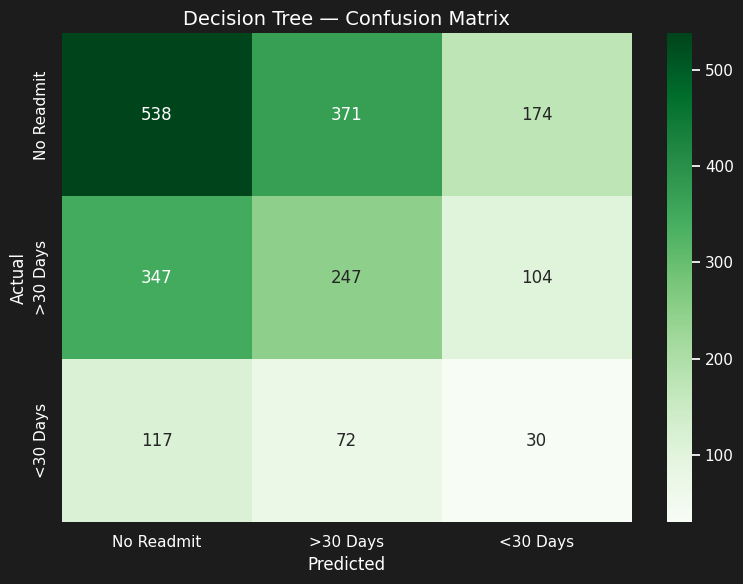

Saved → dt_confusion_matrix.png


In [ ]:
sns.set_theme(style='darkgrid', rc={
    'axes.facecolor': '#242424', 'figure.facecolor': '#1c1c1c',
    'grid.color': '#444444', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white'
})

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Readmit', '>30 Days', '<30 Days'],
            yticklabels=['No Readmit', '>30 Days', '<30 Days'])
plt.title('Decision Tree — Confusion Matrix', color='white', fontsize=14)
plt.ylabel('Actual', color='white')
plt.xlabel('Predicted', color='white')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_confusion_matrix.png')

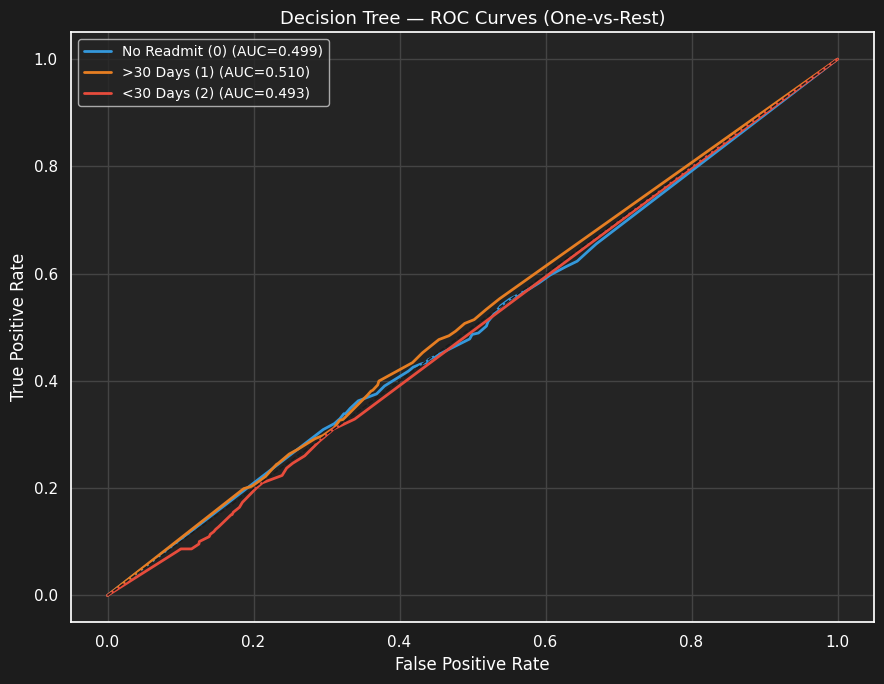

Saved → dt_roc_curves.png


In [ ]:
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']
colors_roc  = ['#3498db', '#e67e22', '#e74c3c']

plt.figure(figsize=(9, 7))
for i, (name, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_i:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('Decision Tree — ROC Curves (One-vs-Rest)', color='white', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dt_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_roc_curves.png')

Cross-Validation F1 (10-fold): 42.34% ± 1.79%


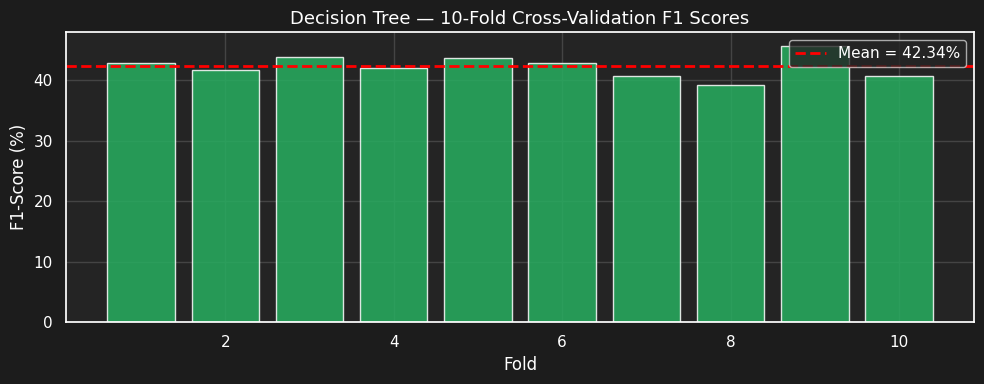

In [ ]:
cv_scores = cross_val_score(dt_best, X_train, y_train,
                            cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                            scoring='f1_weighted', n_jobs=-1)

print(f'Cross-Validation F1 (10-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_scores * 100, color='#27ae60', edgecolor='white', alpha=0.85)
plt.axhline(cv_scores.mean()*100, color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold', color='white')
plt.ylabel('F1-Score (%)', color='white')
plt.title('Decision Tree — 10-Fold Cross-Validation F1 Scores', color='white', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('dt_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# **Step 4 — Explainability Technique 1: SHAP (TreeSHAP)**
### Decision Tree supports exact TreeSHAP — fast and accurate
---

In [ ]:
scaler    = dt_best.named_steps['scaler']
dt_model  = dt_best.named_steps['model']

X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
X_train_scaled = scaler.transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

explainer_shap = shap.TreeExplainer(dt_model)
shap_values_raw = explainer_shap.shap_values(X_test_scaled_df)
# Handle both list and 3D array output from different SHAP versions
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, c] for c in range(shap_values_raw.shape[2])]
else:
    shap_values = shap_values_raw

print('TreeSHAP computation done ')
print(f'SHAP values shape: {np.array(shap_values).shape}')

TreeSHAP computation done 
SHAP values shape: (3, 2000, 26)


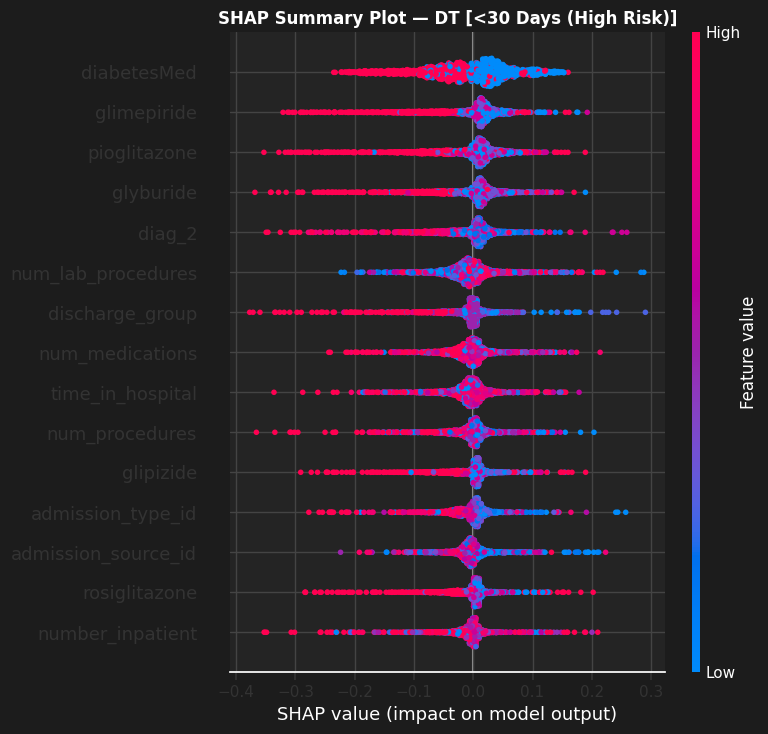

Saved → dt_shap_summary_class2.png


In [ ]:
TARGET_CLASS      = 2
TARGET_CLASS_NAME = '<30 Days (High Risk)'

plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values[TARGET_CLASS],
    X_test_scaled_df,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title(f'SHAP Summary Plot — DT [{TARGET_CLASS_NAME}]',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_shap_summary_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_shap_summary_class2.png')

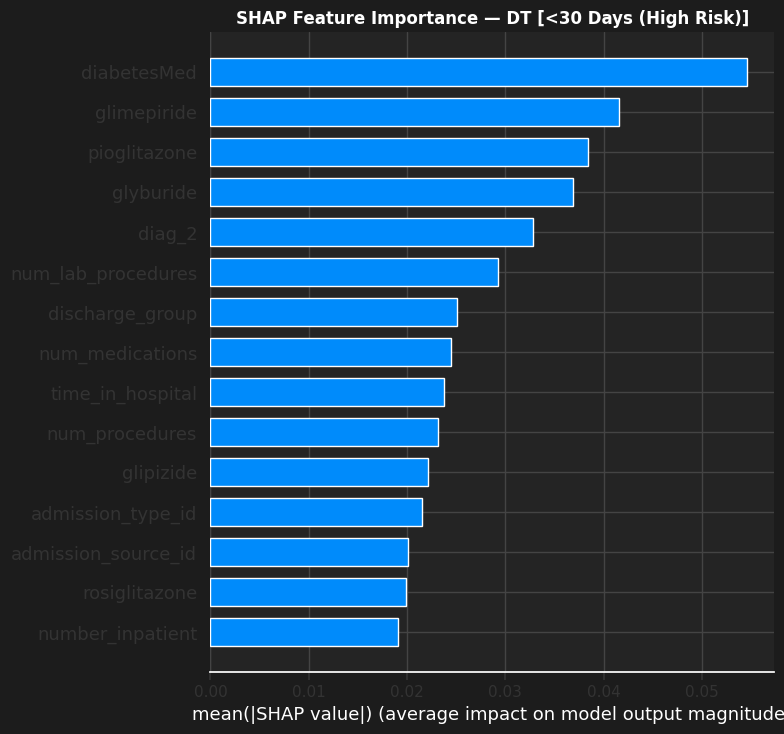

Saved → dt_shap_bar_class2.png


In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[TARGET_CLASS],
    X_test_scaled_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(f'SHAP Feature Importance — DT [{TARGET_CLASS_NAME}]',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_shap_bar_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_shap_bar_class2.png')

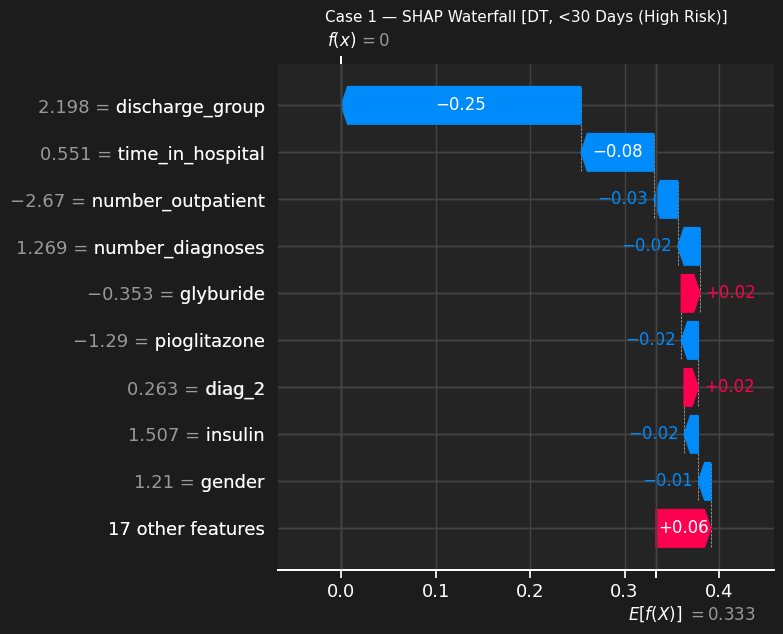

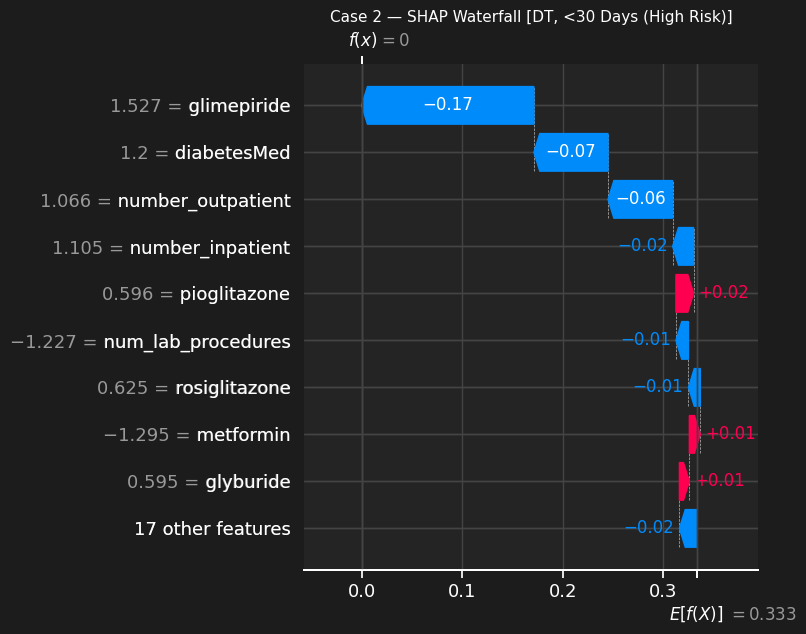

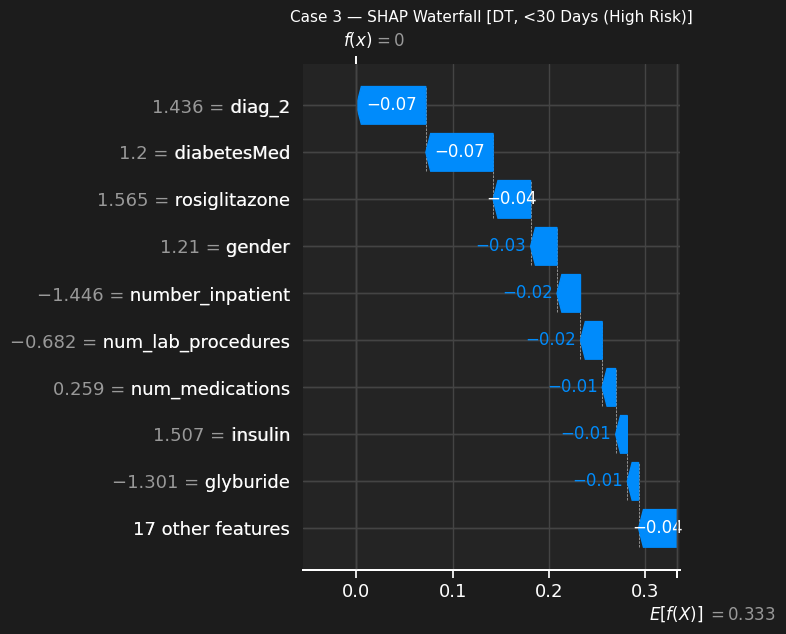

Waterfall plots saved 


In [ ]:
for case_idx, label in [(0, 'Case 1'), (5, 'Case 2'), (10, 'Case 3')]:
    shap_exp = shap.Explanation(
        values      = shap_values[TARGET_CLASS][case_idx],
        base_values = explainer_shap.expected_value[TARGET_CLASS],
        data        = X_test_scaled_df.iloc[case_idx].values,
        feature_names = X.columns.tolist()
    )
    plt.figure(figsize=(12, 4))
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f'{label} — SHAP Waterfall [DT, {TARGET_CLASS_NAME}]', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'dt_shap_waterfall_{label.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Waterfall plots saved ')

# **Step 5 — Explainability Technique 2: LIME**
### Local Instance Explanations
---

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_scaled,
    feature_names  = X.columns.tolist(),
    class_names    = ['No Readmit', '>30 Days', '<30 Days'],
    mode           = 'classification',
    random_state   = 42
)

print('LIME explainer created ')

LIME explainer created 


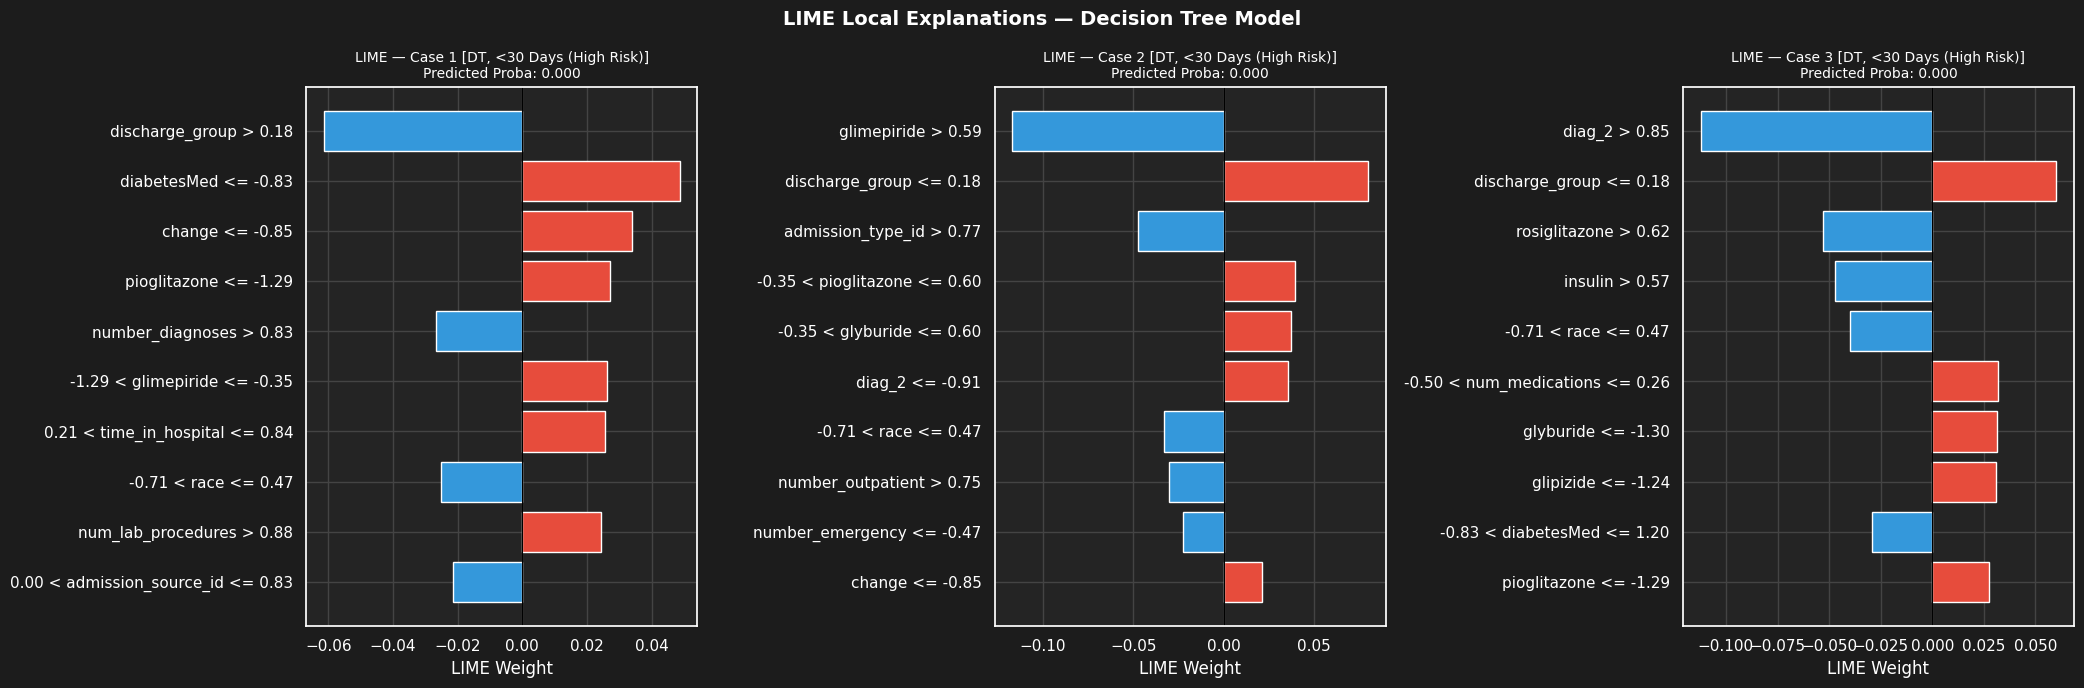

Saved → dt_lime_explanations.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for plot_i, (case_idx, ax) in enumerate(zip([0, 5, 10], axes)):
    exp = lime_explainer.explain_instance(
        data_row   = X_test_scaled_df.iloc[case_idx].values,
        predict_fn = dt_model.predict_proba,
        num_features = 10,
        labels       = (TARGET_CLASS,)
    )

    features_vals  = exp.as_list(label=TARGET_CLASS)
    features_names = [fv[0] for fv in features_vals]
    weights        = [fv[1] for fv in features_vals]
    colors = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

    ax.barh(features_names[::-1], weights[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME — Case {plot_i+1} [DT, {TARGET_CLASS_NAME}]\n'
                 f'Predicted Proba: {dt_model.predict_proba(X_test_scaled_df.iloc[[case_idx]].values)[0][TARGET_CLASS]:.3f}',
                 fontsize=10)
    ax.set_xlabel('LIME Weight')

plt.suptitle('LIME Local Explanations — Decision Tree Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_lime_explanations.png')

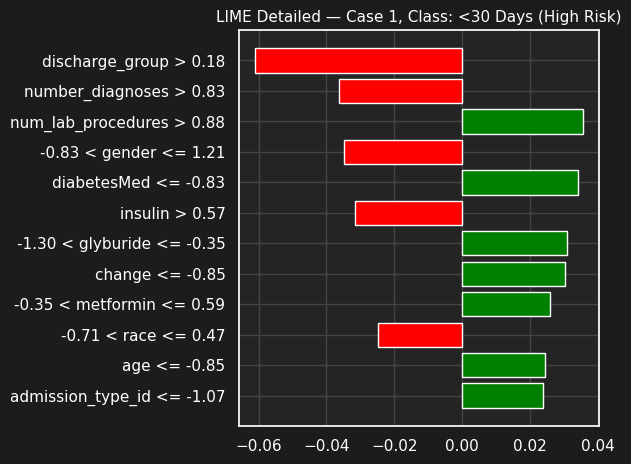

Saved → dt_lime_case1_detail.png


In [ ]:
exp_case1 = lime_explainer.explain_instance(
    data_row   = X_test_scaled_df.iloc[0].values,
    predict_fn = dt_model.predict_proba,
    num_features = 12,
    labels = (0, 1, 2)
)

fig = exp_case1.as_pyplot_figure(label=TARGET_CLASS)
plt.title(f'LIME Detailed — Case 1, Class: {TARGET_CLASS_NAME}', fontsize=11)
plt.tight_layout()
plt.savefig('dt_lime_case1_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_lime_case1_detail.png')

# **Step 6 — Explainability Technique 3: Built-in Feature Importance + Tree Visualization**
### Decision Trees have native interpretability — Gini-based feature importance
---

In [ ]:
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 15 Features by Gini Importance:')
print(feat_imp.head(15).to_string(index=False))

Top 15 Features by Gini Importance:
            Feature  Importance
 num_lab_procedures    0.093495
    num_medications    0.074415
   number_emergency    0.066311
   time_in_hospital    0.062722
admission_source_id    0.062669
  number_outpatient    0.060736
   number_inpatient    0.052190
   number_diagnoses    0.043413
  admission_type_id    0.039368
     num_procedures    0.037457
                age    0.035789
             diag_2    0.032507
    discharge_group    0.031886
       pioglitazone    0.031572
             diag_3    0.031436


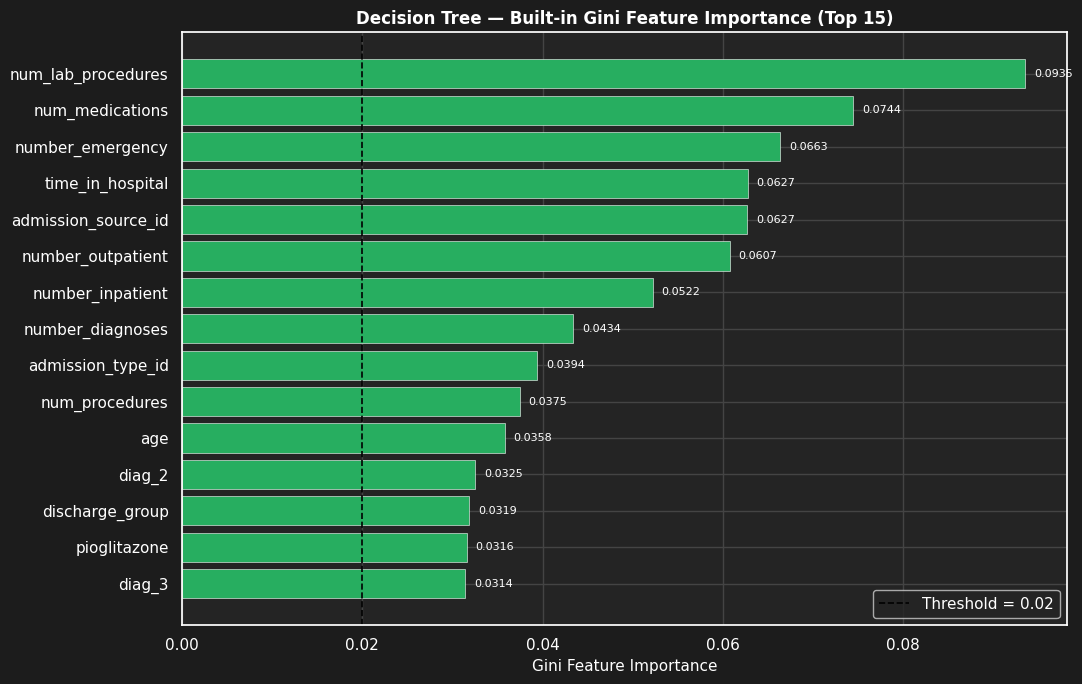

Saved → dt_gini_importance.png


In [ ]:
top15 = feat_imp.head(15)

THRESHOLD = 0.02
colors_imp = ['#27ae60' if v >= THRESHOLD else '#e74c3c'
              for v in top15['Importance']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top15['Feature'][::-1],
    top15['Importance'][::-1],
    color=colors_imp[::-1],
    edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8)

ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.2,
           label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Gini Feature Importance', fontsize=11)
ax.set_title('Decision Tree — Built-in Gini Feature Importance (Top 15)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('dt_gini_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_gini_importance.png')

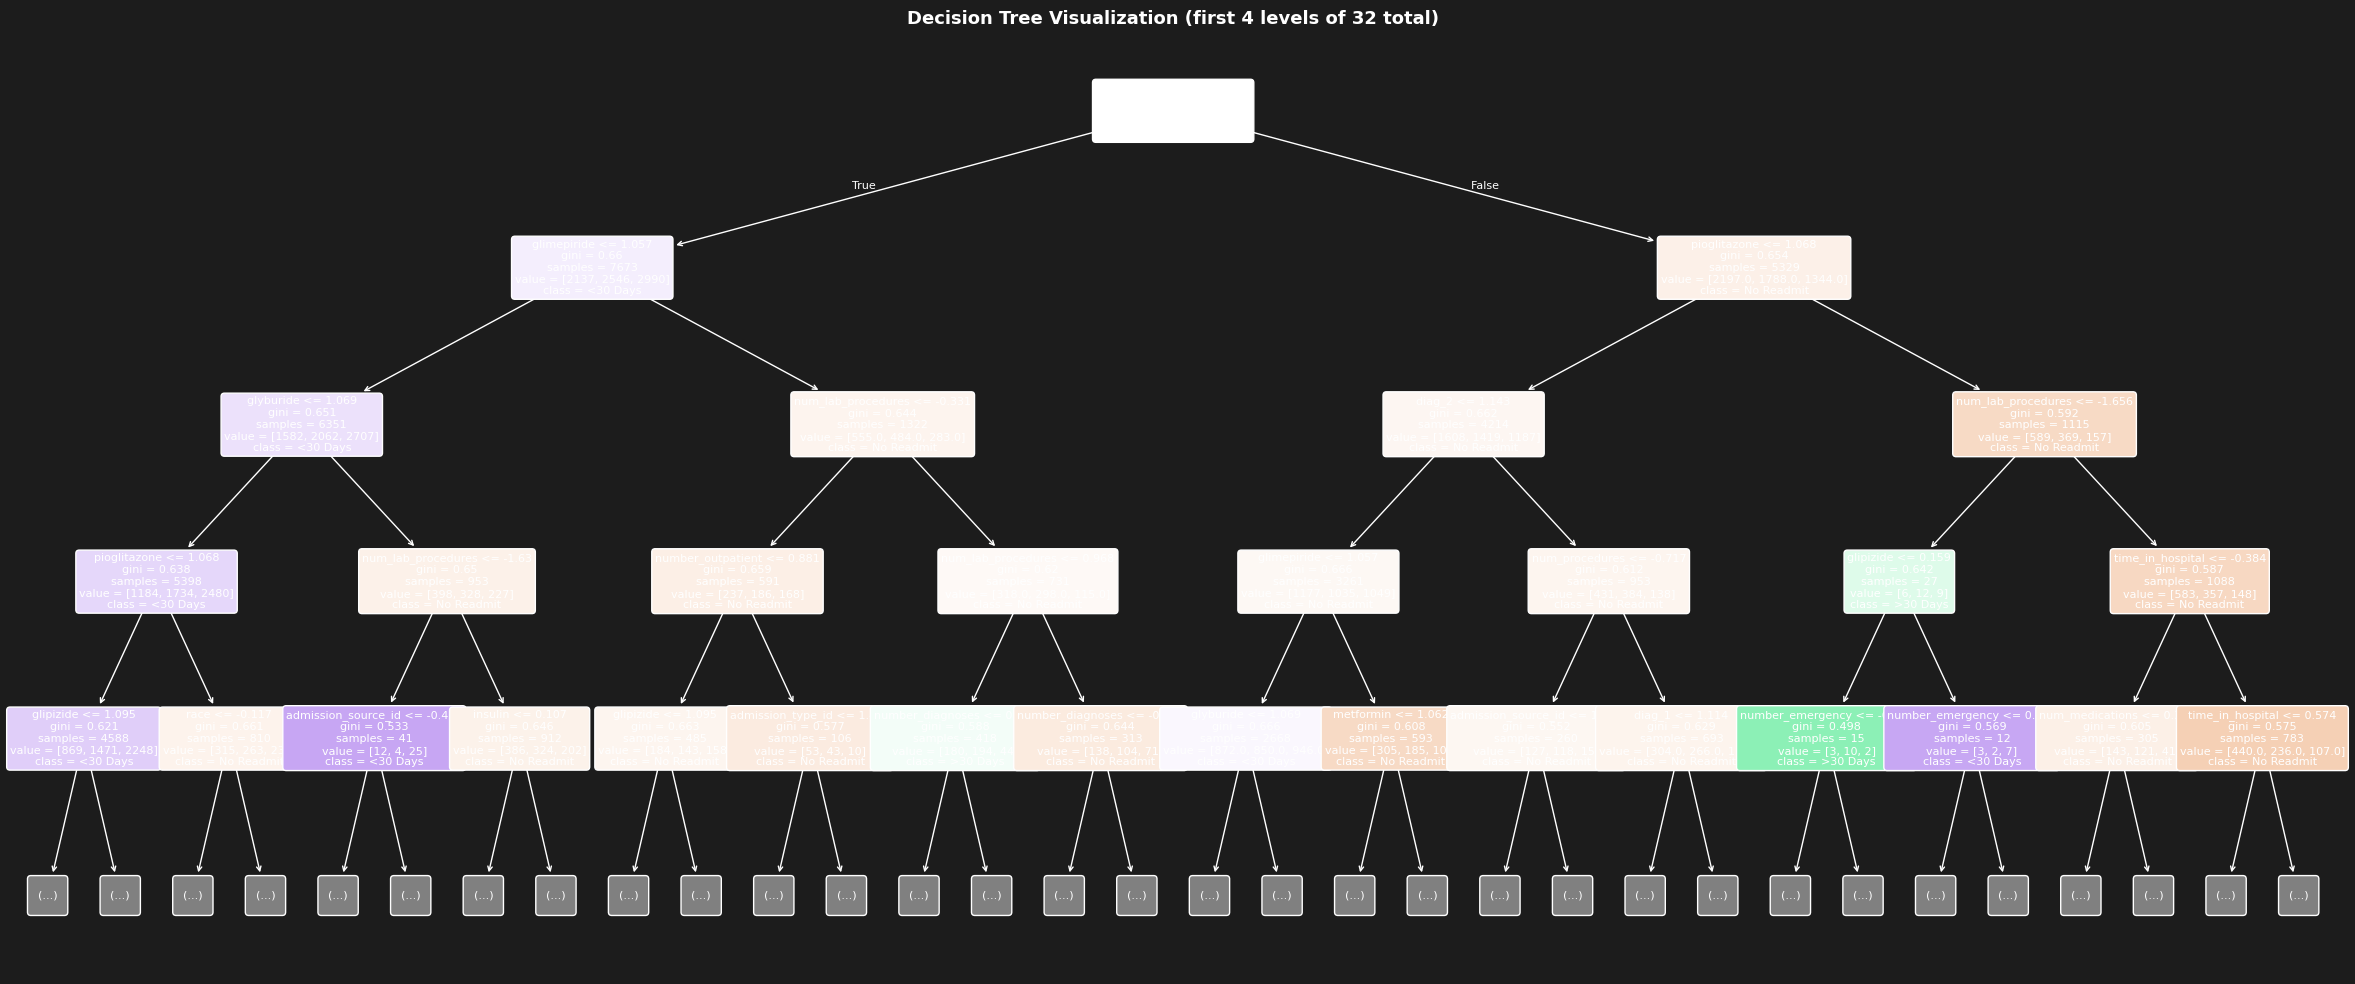

Saved → dt_tree_visualization.png


In [ ]:
best_depth = dt_model.get_depth()
viz_depth  = min(best_depth, 4)

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names = X.columns.tolist(),
    class_names   = ['No Readmit', '>30 Days', '<30 Days'],
    filled        = True,
    rounded       = True,
    max_depth     = viz_depth,
    fontsize      = 8,
    ax            = ax
)
ax.set_title(f'Decision Tree Visualization (first {viz_depth} levels of {best_depth} total)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → dt_tree_visualization.png')

In [ ]:
tree_rules = export_text(
    dt_model,
    feature_names = X.columns.tolist(),
    max_depth     = 3
)
print('Decision Tree Rules (first 3 levels):')
print(tree_rules[:3000])

Decision Tree Rules (first 3 levels):
|--- diabetesMed <= 0.18
|   |--- glimepiride <= 1.06
|   |   |--- glyburide <= 1.07
|   |   |   |--- pioglitazone <= 1.07
|   |   |   |   |--- truncated branch of depth 29
|   |   |   |--- pioglitazone >  1.07
|   |   |   |   |--- truncated branch of depth 15
|   |   |--- glyburide >  1.07
|   |   |   |--- num_lab_procedures <= -1.63
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- num_lab_procedures >  -1.63
|   |   |   |   |--- truncated branch of depth 14
|   |--- glimepiride >  1.06
|   |   |--- num_lab_procedures <= -0.33
|   |   |   |--- number_outpatient <= 0.88
|   |   |   |   |--- truncated branch of depth 13
|   |   |   |--- number_outpatient >  0.88
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- num_lab_procedures >  -0.33
|   |   |   |--- num_lab_procedures <= 0.97
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- num_lab_procedures >  0.97
|   |   |   |   |--- truncated branch of depth 

# **Step 7 — Explainability Technique 4: Partial Dependence Plots (PDP)**
### Shows how each feature marginally affects predicted probability
---

Top 5 features for PDP: ['diabetesMed', 'glimepiride', 'pioglitazone', 'glyburide', 'diag_2']


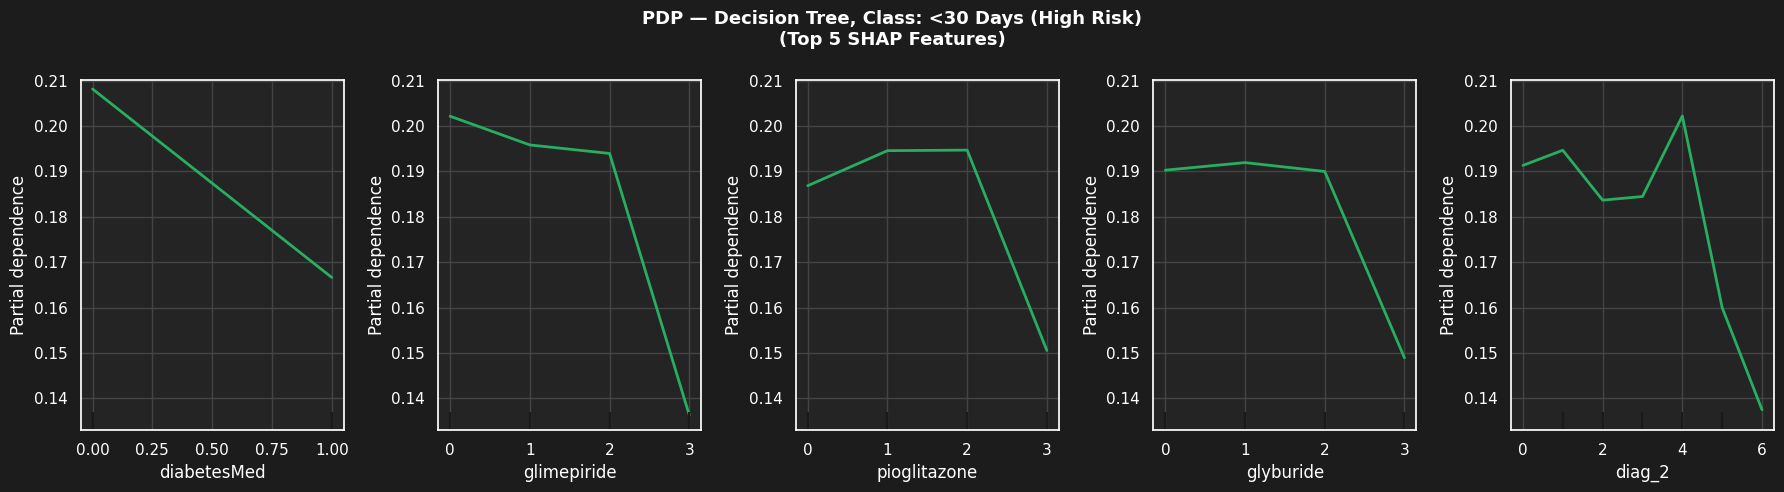

Saved → dt_pdp_top5.png


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class WrappedDT(ClassifierMixin, BaseEstimator):  # ClassifierMixin first ensures is_classifier() works
    def __init__(self, scaler, model):
        self.scaler = scaler
        self.model  = model
        self.classes_ = model.classes_

    def fit(self, X, y):
        self.is_fitted_ = True
        return self
    def __sklearn_is_fitted__(self):
        return True

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X))

    def predict_proba(self, X):
        return self.model.predict_proba(self.scaler.transform(X))

wrapped_dt = WrappedDT(scaler, dt_model)
wrapped_dt.fit(X_train, y_train)  # Mark as fitted

mean_abs_shap = np.abs(shap_values[TARGET_CLASS]).mean(axis=0)
top5_indices  = np.argsort(mean_abs_shap)[::-1][:5]
top5_features = [X.columns[i] for i in top5_indices]

print('Top 5 features for PDP:', top5_features)

fig, axes = plt.subplots(1, len(top5_features), figsize=(18, 5))
PartialDependenceDisplay.from_estimator(
    wrapped_dt,
    X_test,
    features      = top5_indices[:5].tolist(),
    feature_names = X.columns.tolist(),
    target        = TARGET_CLASS,
    kind          = 'average',
    ax            = axes,
    line_kw       = {'color': '#27ae60', 'linewidth': 2}
)

fig.suptitle(f'PDP — Decision Tree, Class: {TARGET_CLASS_NAME}\n(Top 5 SHAP Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_pdp_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_pdp_top5.png')

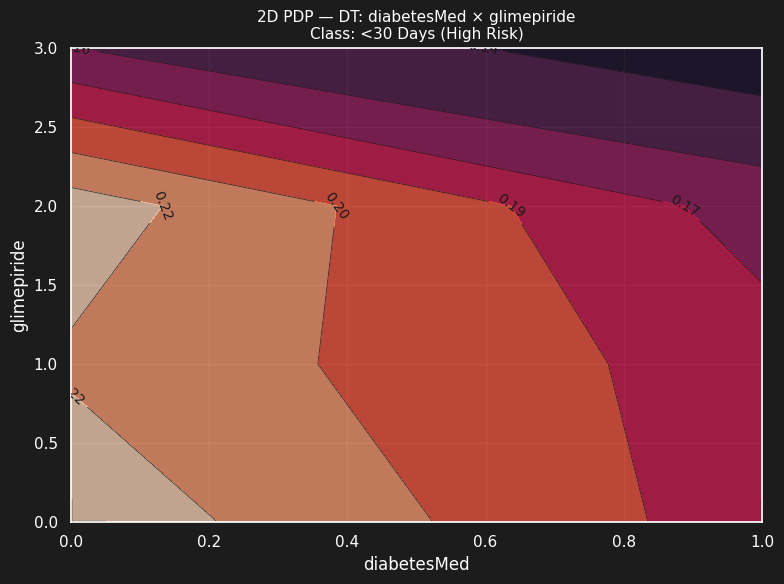

Saved → dt_pdp_2d.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    wrapped_dt,
    X_test,
    features      = [(top5_indices[0], top5_indices[1])],
    feature_names = X.columns.tolist(),
    target        = TARGET_CLASS,
    kind          = 'average',
    ax            = [ax]
)
ax.set_title(f'2D PDP — DT: {top5_features[0]} × {top5_features[1]}\nClass: {TARGET_CLASS_NAME}',
             fontsize=11)
plt.tight_layout()
plt.savefig('dt_pdp_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_pdp_2d.png')

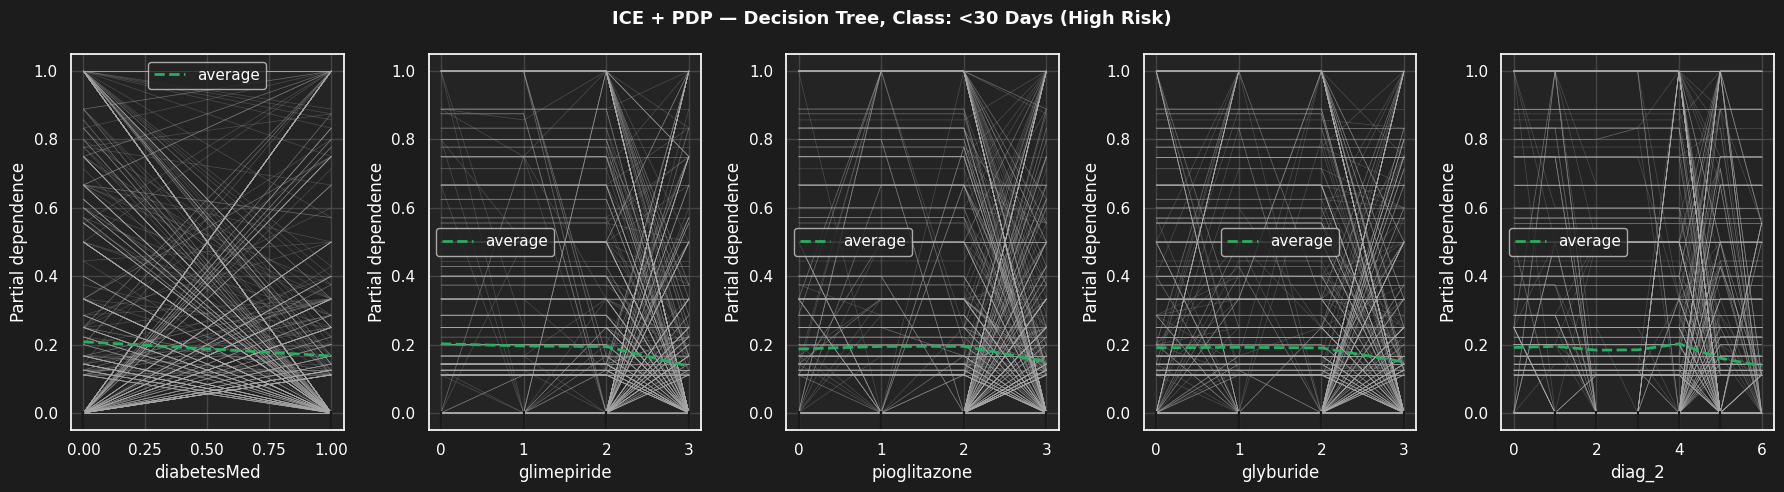

Saved → dt_ice_pdp.png (ICE = Individual Conditional Expectation)


In [ ]:
fig, axes = plt.subplots(1, len(top5_features), figsize=(18, 5))
PartialDependenceDisplay.from_estimator(
    wrapped_dt,
    X_test,
    features      = top5_indices[:5].tolist(),
    feature_names = X.columns.tolist(),
    target        = TARGET_CLASS,
    kind          = 'both',
    ax            = axes,
    pd_line_kw    = {'color': '#27ae60', 'linewidth': 2},
    ice_lines_kw  = {'color': '#aaaaaa', 'alpha': 0.3, 'linewidth': 0.5}
)

fig.suptitle(f'ICE + PDP — Decision Tree, Class: {TARGET_CLASS_NAME}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_ice_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_ice_pdp.png (ICE = Individual Conditional Expectation)')

# **Step 8 — Comparing All 4 Explainability Techniques**
---

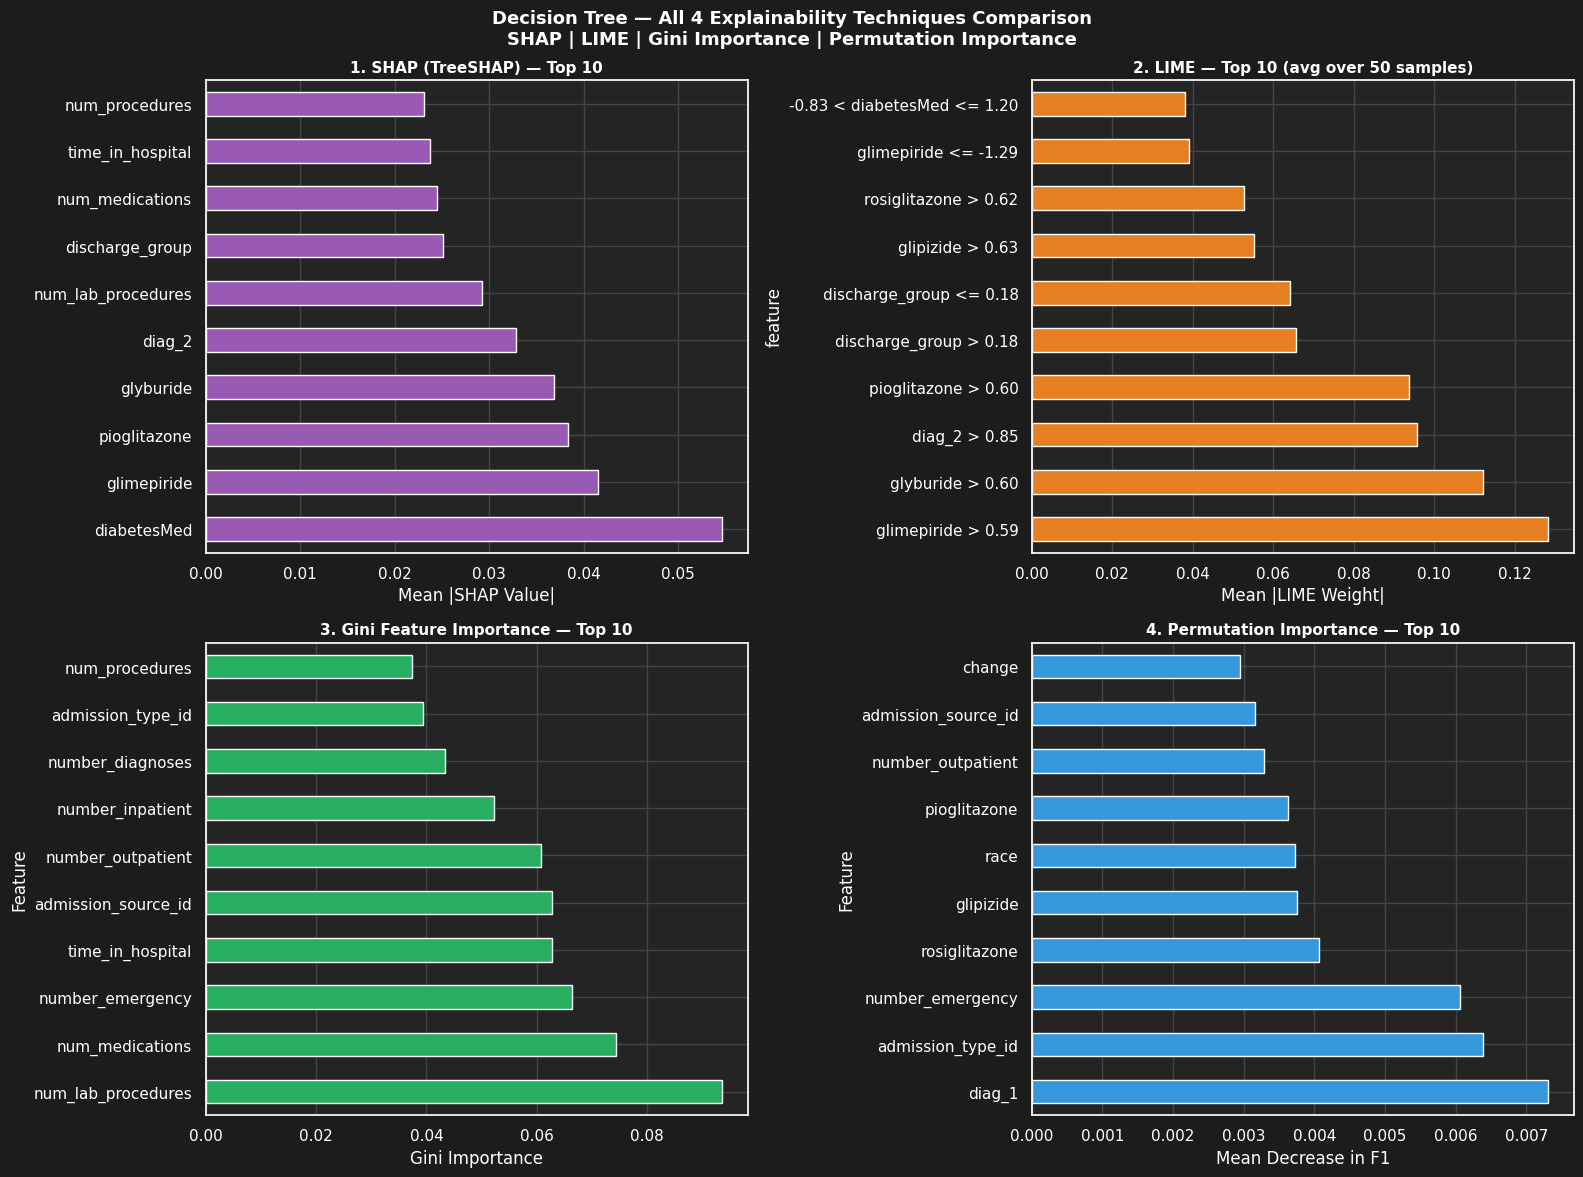

Saved → dt_explainability_comparison.png


In [ ]:
shap_top10 = pd.Series(mean_abs_shap, index=X.columns).nlargest(10)
gini_top10 = feat_imp.set_index('Feature')['Importance'].nlargest(10)

perm_result = permutation_importance(
    wrapped_dt, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='f1_weighted', n_jobs=-1
)
perm_df   = pd.DataFrame({'Feature': X.columns,
                           'Importance_Mean': perm_result.importances_mean})\
              .sort_values('Importance_Mean', ascending=False)
perm_top10 = perm_df.set_index('Feature')['Importance_Mean'].nlargest(10)

lime_weights_all = []
for i in range(50):
    exp_i = lime_explainer.explain_instance(
        X_test_scaled_df.iloc[i].values,
        dt_model.predict_proba,
        num_features=len(X.columns),
        labels=(TARGET_CLASS,)
    )
    for feat, weight in exp_i.as_list(label=TARGET_CLASS):
        lime_weights_all.append({'feature': feat, 'weight': abs(weight)})

lime_df    = pd.DataFrame(lime_weights_all)
lime_top10 = lime_df.groupby('feature')['weight'].mean().nlargest(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

shap_top10.plot(kind='barh', ax=axes[0,0], color='#9b59b6')
axes[0,0].set_title('1. SHAP (TreeSHAP) — Top 10', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Mean |SHAP Value|')

lime_top10.plot(kind='barh', ax=axes[0,1], color='#e67e22')
axes[0,1].set_title('2. LIME — Top 10 (avg over 50 samples)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Mean |LIME Weight|')

gini_top10.plot(kind='barh', ax=axes[1,0], color='#27ae60')
axes[1,0].set_title('3. Gini Feature Importance — Top 10', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Gini Importance')

perm_top10.plot(kind='barh', ax=axes[1,1], color='#3498db')
axes[1,1].set_title('4. Permutation Importance — Top 10', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Mean Decrease in F1')

plt.suptitle('Decision Tree — All 4 Explainability Techniques Comparison\n'
             'SHAP | LIME | Gini Importance | Permutation Importance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_explainability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dt_explainability_comparison.png')

In [ ]:
print('   DECISION TREE MODEL — FINAL SUMMARY')

best_params = grid_search.best_params_
print(f'  Max Depth          : {best_params.get("model__max_depth")}')
print(f'  Min Samples Split  : {best_params.get("model__min_samples_split")}')
print(f'  Min Samples Leaf   : {best_params.get("model__min_samples_leaf")}')
print(f'  Criterion          : {best_params.get("model__criterion")}')
print(f'  Class Weight       : {best_params.get("model__class_weight")}')
print()
print(f'  Accuracy           : {acc:.2f}%')
print(f'  Precision          : {prec:.2f}%')
print(f'  Recall             : {rec:.2f}%')
print(f'  F1-Score           : {f1:.2f}%')
print(f'  AUC-ROC            : {model_auc:.2f}%')
print(f'  CV F1 (10-fold)    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'  Tree Depth         : {dt_model.get_depth()}')
print(f'  Number of Leaves   : {dt_model.get_n_leaves()}')
print()
print('  Explainability Techniques Applied:')
print('   1. SHAP (TreeSHAP) — Summary, Bar, Waterfall plots')
print('   2. LIME            — Local instance explanations')
print('   3. Gini Importance — Built-in DT feature importance + Tree Visualization')
print('   4. PDP / ICE       — Partial Dependence + Individual Conditional Expectation')


   DECISION TREE MODEL — FINAL SUMMARY
  Max Depth          : None
  Min Samples Split  : 10
  Min Samples Leaf   : 1
  Criterion          : gini
  Class Weight       : balanced

  Accuracy           : 40.75%
  Precision          : 42.63%
  Recall             : 40.75%
  F1-Score           : 41.61%
  AUC-ROC            : 50.21%
  CV F1 (10-fold)    : 42.34% ± 1.79%
  Tree Depth         : 32
  Number of Leaves   : 2007

  Explainability Techniques Applied:
   1. SHAP (TreeSHAP) — Summary, Bar, Waterfall plots
   2. LIME            — Local instance explanations
   3. Gini Importance — Built-in DT feature importance + Tree Visualization
   4. PDP / ICE       — Partial Dependence + Individual Conditional Expectation
